<a href="https://colab.research.google.com/github/suhaasteja/nvidia-cosmos-cookoff/blob/main/gs_interior_test_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3D Gaussian Splatting with 3DGUT Tutorial

This notebook demonstrates the NVIDIA 3DGUT (3D Gaussian with Unscented Transforms) workflow for rendering real-world scenes in interactive simulation.

Based on: https://developer.nvidia.com/blog/how-to-instantly-render-real-world-scenes-in-interactive-simulation/

## Workflow Steps:
1. Environment verification
2. Dataset download (NeRF Synthetic Lego)
3. Training with 3DGUT
4. Visualization
5. Export to USD format for Isaac Sim

## 1. Environment Check and Setup

Verify that we're in the correct conda environment and have all necessary dependencies.

In [14]:
%pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [16]:
!conda

usage: conda [-h] [-v] [--no-plugins] [-V] COMMAND ...

conda is a tool for managing and deploying applications, environments and packages.

options:
  -h, --help          Show this help message and exit.
  -v, --verbose       Can be used multiple times. Once for detailed output,
                      twice for INFO logging, thrice for DEBUG logging, four
                      times for TRACE logging.
  --no-plugins        Disable all plugins that are not built into conda.
  -V, --version       Show the conda version number and exit.

commands:
  The following built-in and plugins subcommands are available.

  COMMAND
    activate          Activate a conda environment.
    clean             Remove unused packages and caches.
    commands          List all available conda subcommands (including those
                      from plugins). Generally only used by tab-completion.
    compare           Compare packages between conda environments.
    config            Modify configuration val

In [4]:
!git clone --recursive https://github.com/nv-tlabs/3dgrut.git


Cloning into '3dgrut'...
remote: Enumerating objects: 1398, done.
remote: Counting objects: 100% (864/864), done.
remote: Compressing objects: 100% (438/438), done.
remote: Total 1398 (delta 673), reused 426 (delta 426), pack-reused 534 (from 1)
Receiving objects: 100% (1398/1398), 28.14 MiB | 14.32 MiB/s, done.
Resolving deltas: 100% (855/855), done.
Submodule 'thirdparty/tiny-cuda-nn' (https://github.com/NVlabs/tiny-cuda-nn.git) registered for path 'thirdparty/tiny-cuda-nn'
Submodule 'threedgrt_tracer/dependencies/optix-dev' (https://github.com/NVIDIA/optix-dev.git) registered for path 'threedgrt_tracer/dependencies/optix-dev'
Cloning into '/content/3dgrut/thirdparty/tiny-cuda-nn'...
remote: Enumerating objects: 4475, done.        
remote: Counting objects: 100% (1637/1637), done.        
remote: Compressing objects: 100% (262/262), done.        
remote: Total 4475 (delta 1474), reused 1375 (delta 1375), pack-reused 2838 (from 3)        
Receiving objects: 100% (4475/4475), 19.89 MiB

In [10]:
%pwd
%cd 3dgrut
%pwd

/content/3dgrut


'/content/3dgrut'

In [11]:
%ls

assets/          install_env.ps1   render.py          threedgrut_playground/
ATTRIBUTIONS.md  install_env.sh*   requirements.txt   threedgut_tracer/
benchmark/       LICENSE           setup.py           train.py
configs/         playground.py     thirdparty/
CONTRIBUTING.md  README.md         threedgrt_tracer/
Dockerfile       rebase_helper.sh  threedgrut/


In [17]:
!chmod +x install_env.sh

In [18]:
!./install_env.sh 3dgrut

Streaming output truncated to the last 5000 lines.


                                                                        
                                                                        

                                                                        


                                                                        



                                                                        




                                                                        





                                                                        






                                                                        







                                                                        








                                                                        









                                                                        










                                                                        











     

In [32]:
!conda init


no change     /usr/local/condabin/conda
no change     /usr/local/bin/conda
no change     /usr/local/bin/conda-env
no change     /usr/local/bin/activate
no change     /usr/local/bin/deactivate
no change     /usr/local/etc/profile.d/conda.sh
no change     /usr/local/etc/fish/conf.d/conda.fish
no change     /usr/local/shell/condabin/Conda.psm1
no change     /usr/local/shell/condabin/conda-hook.ps1
no change     /usr/local/lib/python3.11/site-packages/xontrib/conda.xsh
no change     /usr/local/etc/profile.d/conda.csh
no change     /root/.bashrc
No action taken.


In [31]:
!conda activate 3dgrut


CondaError: Run 'conda init' before 'conda activate'



In [27]:
!conda run -n 3dgrut python -c "import torch; print(torch.__version__); print(torch.version.cuda)"

2.10.0+cu128
12.8



In [3]:
%ls

condacolab_install.log  sample_data/


In [28]:
import sys
import os
import subprocess

# Check Python version
print(f"Python version: {sys.version}")
print(f"Python executable: {sys.executable}")

# Check if we're in the 3dgrut environment
conda_env = os.environ.get('CONDA_DEFAULT_ENV', 'unknown')
print(f"\nConda environment: {conda_env}")

if conda_env != '3dgrut':
    print("\n⚠️  WARNING: Not in 3dgrut conda environment!")
    print("Please run: conda activate 3dgrut")
    print("Then restart this notebook kernel.")
else:
    print("✓ Correct environment activated")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Python executable: /usr/bin/python3.real

Conda environment: unknown

⚠️  WARNING: Not in 3dgrut conda environment!
Please run: conda activate 3dgrut
Then restart this notebook kernel.


In [33]:
# Check CUDA availability
try:
    import torch
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        print("✓ CUDA is ready")
    else:
        print("⚠️  WARNING: CUDA not available!")
except ImportError:
    print("⚠️  ERROR: PyTorch not installed!")
    print("Please ensure the 3dgrut environment is properly installed.")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA A100-SXM4-40GB
GPU memory: 42.41 GB
✓ CUDA is ready


In [34]:
# Set up paths
WORK_DIR = "/content/"
REPO_DIR = os.path.join(WORK_DIR, "3dgrut")
DATA_DIR = os.path.join(WORK_DIR, "data")
OUTPUT_DIR = os.path.join(WORK_DIR, "runs")

# Change to repo directory
os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

# Create data and output directories
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Working directory: /content/3dgrut
Data directory: /content/data
Output directory: /content/runs


In [67]:
!apt-get install colmap

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libamd2 libatk-bridge2.0-0
  libatk1.0-0 libatk1.0-data libatspi2.0-0 libcamd2 libccolamd2 libceres2
  libcholmod3 libcolamd2 libcxsparse3 libdouble-conversion3 libevdev2
  libfreeimage3 libgflags2.2 libglew2.2 libgoogle-glog0v5 libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libilmbase25 libinput-bin
  libinput10 libjxr0 libmd4c0 libmetis5 libmtdev1 libopenexr25 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libraw20
  librsvg2-common libspqr2 libsuitesparseconfig5 libwacom-bin libwacom-common
  libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1 libxcb-render-util0
  libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1 libxcomposite1
  libxkbcommon-x11-0 libxtst6 qt5-gtk-platformtheme qttranslations5-l10n
  session-migration
Suggested packages:
  gle

In [69]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [70]:
# Change this to your actual folder name in Drive
DRIVE_IMAGE_FOLDER = '/content/drive/MyDrive/interior_images'

import os
if os.path.exists(DRIVE_IMAGE_FOLDER):
    print(f"✓ Found {len(os.listdir(DRIVE_IMAGE_FOLDER))} images in {DRIVE_IMAGE_FOLDER}")
else:
    print("⚠️ Folder not found. Please check the path in your Drive.")

✓ Found 116 images in /content/drive/MyDrive/interior_images


In [71]:
import os
os.makedirs('/content/colmap/sparse', exist_ok=True)

In [72]:
import os

os.listdir("/content/")

['.config',
 'runs',
 'drive',
 'condacolab_install.log',
 '3dgrut',
 'data',
 'colmap',
 'sample_data']

In [74]:
!export QT_QPA_PLATFORM=offscreen && \
colmap feature_extractor \
    --database_path /content/colmap/database.db \
    --image_path /content/drive/MyDrive/interior_images \
    --ImageReader.single_camera 1 \
    --ImageReader.camera_model PINHOLE \
    --SiftExtraction.max_image_size 2000 \
    --SiftExtraction.estimate_affine_shape 1 \
    --SiftExtraction.domain_size_pooling 1

QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'

Feature extraction

Processed file [1/116]
  Name:            frame_0001.jpg
  Dimensions:      480 x 848
  Camera:          #1 - PINHOLE
  Focal Length:    1017.60px
  Features:        1369
Processed file [2/116]
  Name:            frame_0002.jpg
  Dimensions:      480 x 848
  Camera:          #1 - PINHOLE
  Focal Length:    1017.60px
  Features:        1502
Processed file [3/116]
  Name:            frame_0014.jpg
  Dimensions:      480 x 848
  Camera:          #1 - PINHOLE
  Focal Length:    1017.60px
  Features:        1280
Processed file [4/116]
  Name:            frame_0003.jpg
  Dimensions:      480 x 848
  Camera:          #1 - PINHOLE
  Focal Length:    1017.60px
  Features:        1528
Processed file [5/116]
  Name:            frame_0008.jpg
  Dimensions:      480 x 848
  Camera:          #1 - PINHOLE
  Focal Length:    1017.60px
  Features:        1401
Processed file [6/116]
  Name:            frame_0

In [77]:
!export QT_QPA_PLATFORM=offscreen && \
colmap exhaustive_matcher \
    --database_path /content/colmap/database.db \
    --SiftMatching.use_gpu 0


Exhaustive feature matching

Matching block [1/3, 1/3] in 16.623s
Matching block [1/3, 2/3] in 19.142s
Matching block [1/3, 3/3] in 2.977s
Matching block [2/3, 1/3] in 17.612s
Matching block [2/3, 2/3] in 19.795s
Matching block [2/3, 3/3] in 2.374s
Matching block [3/3, 1/3] in 11.230s
Matching block [3/3, 2/3] in 12.485s
Matching block [3/3, 3/3] in 2.580s
Elapsed time: 1.747 [minutes]


In [78]:
!export QT_QPA_PLATFORM=offscreen && \
colmap mapper \
    --database_path /content/colmap/database.db \
    --image_path /content/drive/MyDrive/interior_images \
    --output_path /content/colmap/sparse

Streaming output truncated to the last 5000 lines.

Bundle adjustment report
------------------------
    Residuals : 6170
   Parameters : 584
   Iterations : 6
         Time : 0.029989 [s]
 Initial cost : 0.522121 [px]
   Final cost : 0.507696 [px]
  Termination : Convergence

  => Merged observations: 18
  => Completed observations: 14
  => Filtered observations: 37
  => Changed observations: 0.020093

Bundle adjustment report
------------------------
    Residuals : 6062
   Parameters : 575
   Iterations : 2
         Time : 0.0106871 [s]
 Initial cost : 0.619148 [px]
   Final cost : 0.612771 [px]
  Termination : Convergence

  => Merged observations: 0
  => Completed observations: 12
  => Filtered observations: 0
  => Changed observations: 0.003513

Registering image #85 (43)

  => Image sees 162 / 250 points

Pose refinement report
----------------------
    Residuals : 320
   Parameters : 6
   Iterations : 6
         Time : 0.00159097 [s]
 Initial cost : 0.627763 [px]
   Final cos

In [79]:
import os

colmap_path = "/content/colmap/sparse/0"
required_files = ["cameras.bin", "images.bin", "points3D.bin"]

print("Checking COLMAP output structure...")
if os.path.exists(colmap_path):
    found_files = os.listdir(colmap_path)
    all_present = True
    for f in required_files:
        if f in found_files:
            print(f"✓ {f} found.")
        else:
            print(f"✗ {f} is MISSING!")
            all_present = False

    if all_present:
        print("\n✅ Structure is correct! You are ready to run the training command.")
    else:
        print("\n⚠️ COLMAP mapper may have failed or is still running.")
else:
    print(f"\n❌ Directory {colmap_path} not found. Check if 'colmap mapper' finished successfully.")

Checking COLMAP output structure...
✓ cameras.bin found.
✓ images.bin found.
✓ points3D.bin found.

✅ Structure is correct! You are ready to run the training command.


## 2. Dataset Download

Download the NeRF Synthetic Lego dataset. This is a small synthetic scene perfect for testing.

In [35]:
import urllib.request
import zipfile
import json
from pathlib import Path

# Dataset URL (using a mirror since the original might require authentication)
DATASET_URL = "https://huggingface.co/datasets/nerfbaselines/nerfbaselines-data/resolve/main/blender/lego.zip"
DATASET_NAME = "lego"
DATASET_PATH = os.path.join(DATA_DIR, "nerf_synthetic", DATASET_NAME)

def download_dataset():
    """Download and extract the NeRF Synthetic Lego dataset."""

    # Check if already downloaded
    if os.path.exists(DATASET_PATH) and os.path.exists(os.path.join(DATASET_PATH, "transforms_train.json")):
        print(f"✓ Dataset already exists at {DATASET_PATH}")
        return True

    print(f"Downloading dataset from {DATASET_URL}...")
    zip_path = os.path.join(DATA_DIR, "lego.zip")

    try:
        # Download
        urllib.request.urlretrieve(DATASET_URL, zip_path)
        print(f"✓ Downloaded to {zip_path}")

        # Extract
        print("Extracting...")
        os.makedirs(os.path.dirname(DATASET_PATH), exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(os.path.dirname(DATASET_PATH))

        # Clean up zip file
        os.remove(zip_path)
        print(f"✓ Dataset extracted to {DATASET_PATH}")
        return True

    except Exception as e:
        print(f"⚠️  Error downloading dataset: {e}")
        print("\nAlternative: Download manually from:")
        print("https://www.kaggle.com/datasets/nguyenhung1903/nerf-synthetic-dataset")
        print(f"Extract to: {DATASET_PATH}")
        return False

download_dataset()

✓ Downloaded to /content/data/lego.zip
Extracting...
✓ Dataset extracted to /content/data/nerf_synthetic/lego


True

In [36]:
# Verify dataset structure
def verify_dataset():
    """Check if dataset has the expected structure."""
    required_files = [
        "transforms_train.json",
        "transforms_test.json",
        "transforms_val.json"
    ]

    print("Checking dataset structure...")
    all_good = True

    for file in required_files:
        path = os.path.join(DATASET_PATH, file)
        if os.path.exists(path):
            print(f"✓ {file}")
        else:
            print(f"✗ {file} - MISSING")
            all_good = False

    # Check for images
    train_dir = os.path.join(DATASET_PATH, "train")
    if os.path.exists(train_dir):
        num_images = len([f for f in os.listdir(train_dir) if f.endswith('.png')])
        print(f"✓ Found {num_images} training images")
    else:
        print(f"✗ train/ directory - MISSING")
        all_good = False

    if all_good:
        print("\n✓ Dataset structure is valid!")
    else:
        print("\n⚠️  Dataset structure is incomplete!")

    return all_good

verify_dataset()

Checking dataset structure...
✓ transforms_train.json
✓ transforms_test.json
✓ transforms_val.json
✓ Found 100 training images

✓ Dataset structure is valid!


True

## 3. Training Configuration

Set up the training configuration for 3DGUT. We'll use the NeRF Synthetic config with options to export to USD format.

In [37]:
# Training parameters
CONFIG_NAME = "apps/nerf_synthetic_3dgut.yaml"
EXPERIMENT_NAME = "lego_3dgut_tutorial"
N_ITERATIONS = 30000  # Reduce to 1000 for quick testing
EXPORT_USD = True

print("Training Configuration:")
print(f"  Config: {CONFIG_NAME}")
print(f"  Dataset: {DATASET_PATH}")
print(f"  Output: {OUTPUT_DIR}/{EXPERIMENT_NAME}")
print(f"  Iterations: {N_ITERATIONS}")
print(f"  Export USD: {EXPORT_USD}")
print(f"\nEstimated training time: ~{N_ITERATIONS//1000 * 0.5:.1f} minutes")

Training Configuration:
  Config: apps/nerf_synthetic_3dgut.yaml
  Dataset: /content/data/nerf_synthetic/lego
  Output: /content/runs/lego_3dgut_tutorial
  Iterations: 30000
  Export USD: True

Estimated training time: ~15.0 minutes


## 4. Train with 3DGUT

Run the training process. This will:
1. Initialize 3D Gaussians from the dataset
2. Optimize Gaussian parameters using the 3DGUT method
3. Save checkpoints at iterations 7000 and 30000
4. Export to USD format (if enabled)

In [47]:
!conda run -n 3dgrut pip install viser

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 99.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.3/740.3 kB 48.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 166.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 78.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 186.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.8 MB/s  0:00:00




In [43]:
# Build the training command
train_cmd = [
    "conda", "run", "-n", "3dgrut",  # Add this prefix
    "python", "train.py",
    f"--config-name={CONFIG_NAME}",
    f"path={DATASET_PATH}",
    f"out_dir={OUTPUT_DIR}",
    f"experiment_name={EXPERIMENT_NAME}",
    f"n_iterations={N_ITERATIONS}",
]

if EXPORT_USD:
    train_cmd.extend([
        "export_usdz.enabled=true",
        "export_usdz.apply_normalizing_transform=true"
    ])

print("Training command:")
print(" ".join(train_cmd))
print("\nStarting training...\n")

Training command:
conda run -n 3dgrut python train.py --config-name=apps/nerf_synthetic_3dgut.yaml path=/content/data/nerf_synthetic/lego out_dir=/content/runs experiment_name=lego_3dgut_tutorial n_iterations=30000 export_usdz.enabled=true export_usdz.apply_normalizing_transform=true

Starting training...



In [45]:
import subprocess
import os

try:
    # Use the full path to conda if 'conda' alone isn't found
    result = subprocess.run(
        train_cmd,
        cwd=REPO_DIR,
        capture_output=True, # We keep this to capture the log
        text=True
    )

    if result.returncode == 0:
        print("\n✓ Training completed successfully!")
        print(result.stdout[-500:]) # Print the end of the success log
    else:
        print(f"\n⚠️ Training failed with exit code {result.returncode}")
        # THIS IS THE CRITICAL PART: Print the error message
        print("\n--- ERROR LOG ---")
        print(result.stderr)
        print(result.stdout[-1000:]) # Print the last 1000 chars of output

except Exception as e:
    print(f"\n⚠️ Error during training: {e}")


⚠️  Training failed with exit code 1


In [48]:
# testing on 100 images
!conda run -n 3dgrut python train.py --config-name=apps/nerf_synthetic_3dgut.yaml path=/content/data/nerf_synthetic/lego out_dir=/content/runs experiment_name=lego_tutorial n_iterations=100

[20:46:22] [INFO] Git hash:                                         logger.py:67
           a03c594e66e0900f3fb784d6c2c6b0e2518c70c7                             
           [INFO] Compiling native code..                           logger.py:67
──────────────────────────────── Load Datasets ─────────────────────────────────
Load Dataset (train) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% :: 🕒 Elapsed 0:00:00
Load Dataset (val) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% :: 🕒 Elapsed 0:00:00
─────────────────────────────── Initialize Model ───────────────────────────────
[1/5] /usr/local/envs/3dgrut/bin/x86_64-conda-linux-gnu-c++ -MMD -MF cudaBuffer.o.d -DTORCH_EXTENSION_NAME=lib3dgut_cc -DTORCH_API_INCLUDE_EXTENSION_H -I/usr/local/envs/3dgrut/targets/x86_64-linux/include -I/content/3dgrut/threedgut_tracer/include -I/content/3dgrut/thirdparty/tiny-cuda-nn/include -I/content/3dgrut/thirdparty/tiny-cuda-nn/dependencies -I/content/3dgrut/thirdparty/tiny-cuda-nn/dependencies/fmt/include -I/root/.cache/

In [57]:
# running all
!conda run -n 3dgrut python train.py --config-name=apps/nerf_synthetic_3dgut.yaml path=/content/data/nerf_synthetic/lego out_dir=/content/runs experiment_name=lego_3dgut_tutorial n_iterations=30000 export_usdz.enabled=true export_usdz.apply_normalizing_transform=true

[21:03:16] [INFO] Git hash:                                         logger.py:67
           a03c594e66e0900f3fb784d6c2c6b0e2518c70c7                             
           [INFO] Compiling native code..                           logger.py:67
──────────────────────────────── Load Datasets ─────────────────────────────────
Load Dataset (train) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% :: 🕒 Elapsed 0:00:00
Load Dataset (val) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% :: 🕒 Elapsed 0:00:00
─────────────────────────────── Initialize Model ───────────────────────────────
ninja: no work to do.
[21:03:22] [INFO] 🔆 Using GS strategy                              logger.py:67
──────────────────────── Setup Model Weights & Training ────────────────────────
[21:03:24] [INFO] 🤸 Initiating new 3dgrut training..               logger.py:67
           [INFO] Generating random point cloud (100000)...         logger.py:67
           [INFO] 🔆 Using Adam optimizer                           logger.py:67
           

In [81]:
import os

# 1. Define paths
drive_path = '/content/drive/MyDrive/interior_images'
colmap_images_path = '/content/colmap/images'

# 2. Create the link
if not os.path.exists(colmap_images_path):
    os.symlink(drive_path, colmap_images_path)
    print(f"✅ Created shortcut: {colmap_images_path} -> {drive_path}")
else:
    print("ℹ️ Link already exists.")

# 3. Verify images are visible through the link
test_file = os.path.join(colmap_images_path, 'frame_0110.jpg')
if os.path.exists(test_file):
    print(f"✓ Success! Found {test_file}")
else:
    print(f"⚠️ Warning: Still can't find {test_file}. Check your folder name on Drive.")

✅ Created shortcut: /content/colmap/images -> /content/drive/MyDrive/interior_images
✓ Success! Found /content/colmap/images/frame_0110.jpg


In [82]:
!conda run -n 3dgrut python train.py --config-name apps/colmap_3dgut_mcmc.yaml \
    path=/content/colmap/ \
    out_dir=/content/runs/ \
    experiment_name=my_interior_scene \
    export_usdz.enabled=true \
    export_usdz.apply_normalizing_transform=true

[22:22:12] [INFO] Git hash:                                         logger.py:67
           a03c594e66e0900f3fb784d6c2c6b0e2518c70c7                             
           [INFO] Compiling native code..                           logger.py:67
──────────────────────────────── Load Datasets ─────────────────────────────────
[22:22:16] [INFO] 📷 EXIF: No exposure data found in 16 images      logger.py:67
Load Dataset (train) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% :: 🕒 Elapsed 0:00:00
Load Dataset (val) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% :: 🕒 Elapsed 0:00:00
─────────────────────────────── Initialize Model ───────────────────────────────
ninja: no work to do.
ninja: no work to do.
[22:22:18] [INFO] 🔆 Using MCMC strategy                            logger.py:67
──────────────────────── Setup Model Weights & Training ────────────────────────
[22:22:19] [INFO] 🤸 Initiating new 3dgrut training..               logger.py:67
           [INFO] Found 21 colmap points                            lo

## 5. Check Training Results

Verify that training completed and checkpoints were saved.

Showing results from latest run: /content/runs/my_interior_scene/colmap-0103_222220

Displaying: 00000.png


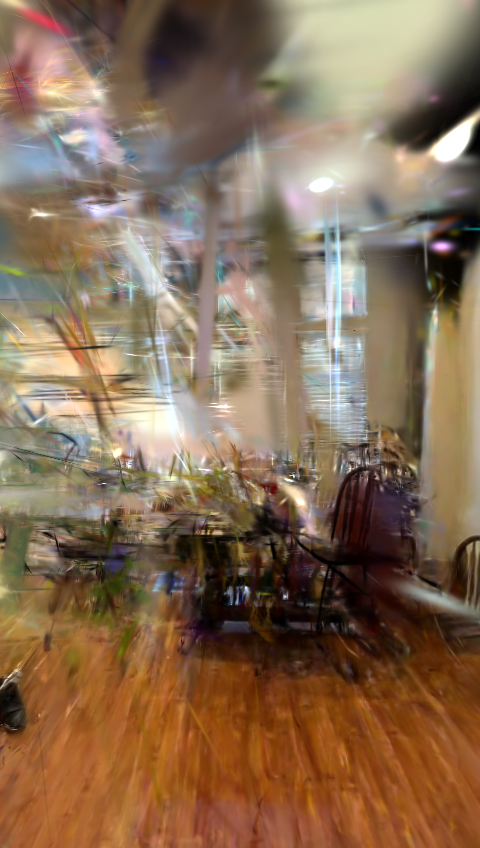

Displaying: 00001.png


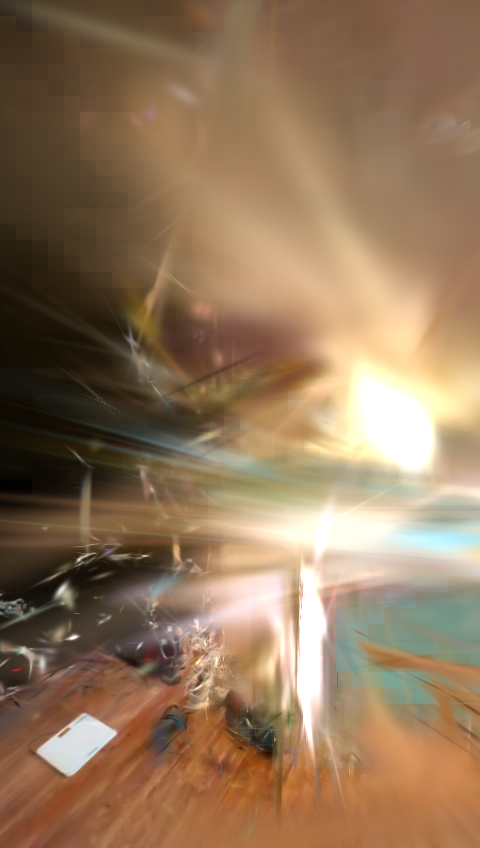

In [84]:
import glob
import os
from IPython.display import Image, display

# 1. Path to your experiment
base_dir = "/content/runs/my_interior_scene/"

# 2. Automatically find the LATEST timestamped folder
# (This ensures you see the most recent run, not an old one)
subdirs = [os.path.join(base_dir, d) for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
actual_dir = max(subdirs, key=os.path.getmtime)

print(f"Showing results from latest run: {actual_dir}\n")

# 3. Path to the renders at 30,000 iterations
render_dir = os.path.join(actual_dir, "ours_30000/renders")

if os.path.exists(render_dir):
    # Get the first 5 rendered images
    images = sorted(glob.glob(os.path.join(render_dir, "*.png")))[:5]

    if not images:
        print(f"⚠️ No images found in {render_dir}. Check if training finished.")
    else:
        for img in images:
            print(f"Displaying: {os.path.basename(img)}")
            display(Image(filename=img, width=500))
else:
    print(f"❌ Render directory not found: {render_dir}")
    print("If your training is still running, this folder will appear once it hits 30k iterations.")

In [88]:
import subprocess
import glob
import os
import base64
from IPython.display import HTML, display

# 1. Use the 'render_dir' we defined in the previous step
# (This points to /content/runs/my_interior_scene/latest_run/ours_30000/renders)
output_video_name = 'my_interior_reconstruction.mp4'

def create_video_from_renders(render_folder, output_path, fps=24):
    """Create MP4 video from rendered images."""
    image_files = sorted(glob.glob(os.path.join(render_folder, '*.png')))

    if not image_files:
        print(f"⚠️ No images found in {render_folder}")
        return None

    print(f"Creating video from {len(image_files)} images at {fps} FPS...")

    # Create a temporary file list for ffmpeg
    list_file = '/tmp/interior_image_list.txt'
    with open(list_file, 'w') as f:
        for img in image_files:
            f.write(f"file '{img}'\n")
            f.write(f"duration {1.0/fps}\n")
        # FFMPEG concat demuxer needs the last file repeated to show the last frame
        f.write(f"file '{image_files[-1]}'\n")

    # Use ffmpeg to create video
    cmd = [
        'ffmpeg', '-y', '-f', 'concat', '-safe', '0',
        '-i', list_file,
        '-pix_fmt', 'yuv420p',
        '-vf', f'fps={fps},pad=ceil(iw/2)*2:ceil(ih/2)*2', # Ensures even dimensions for H.264
        output_path
    ]

    try:
        result = subprocess.run(cmd, capture_output=True, text=True)
        if result.returncode == 0:
            print(f"✓ Video created successfully: {output_path}")
            return output_path
        else:
            print(f"⚠️ ffmpeg error: {result.stderr}")
            return None
    except FileNotFoundError:
        print("⚠️ ffmpeg not found. Install with: !apt-get install ffmpeg")
        return None

def display_video(video_path):
    """Display video in notebook."""
    with open(video_path, 'rb') as f:
        video_data = f.read()
    video_base64 = base64.b64encode(video_data).decode('ascii')
    video_html = f'''
    <video width="800" controls autoplay loop>
        <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
    </video>
    '''
    return HTML(video_html)

# Execute
video_path = create_video_from_renders(render_dir, output_video_name, fps=0.05)
if video_path:
    display(display_video(video_path))

Creating video from 2 images at 0.05 FPS...
✓ Video created successfully: my_interior_reconstruction.mp4


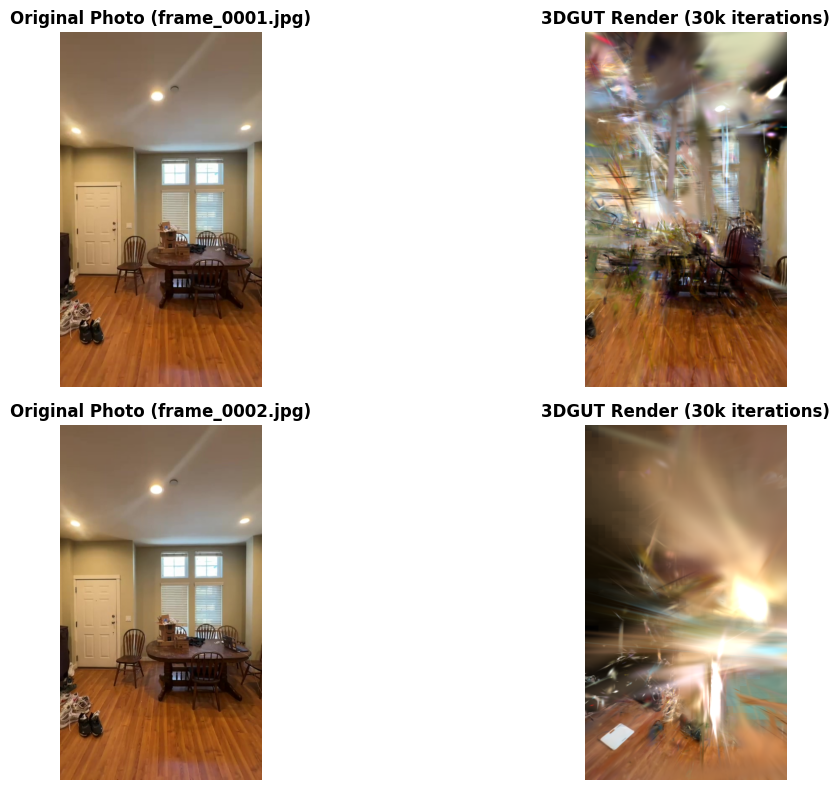

✓ Showing 2 comparisons between original photos and 3D renders


In [96]:
# Before/After Training Comparison for Interior Images
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import glob
import os

# 1. Update to your actual image path on Drive
# The 'render_dir' is already handled by the 'latest run' logic we ran earlier
dataset_path = '/content/drive/MyDrive/interior_images'

# 2. Find your original images (Ground Truth)
# We use the main folder since COLMAP uses all images for training/val
test_images = sorted(glob.glob(os.path.join(dataset_path, '*.jpg')))

# 3. Find the images rendered by 3DGUT
rendered_images = sorted(glob.glob(os.path.join(render_dir, '*.png')))

if test_images and rendered_images:
    # Show 4 comparisons
    num_comparisons = min(4, len(test_images), len(rendered_images))

    fig, axes = plt.subplots(num_comparisons, 2, figsize=(14, 4*num_comparisons))
    if num_comparisons == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_comparisons):
        # Original Image (Ground Truth)
        gt_img = PILImage.open(test_images[i])
        axes[i, 0].imshow(gt_img)
        axes[i, 0].set_title(f'Original Photo ({os.path.basename(test_images[i])})', fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')

        # 3DGUT Model Output
        rendered_img = PILImage.open(rendered_images[i])
        axes[i, 1].imshow(rendered_img)
        axes[i, 1].set_title(f'3DGUT Render (30k iterations)', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"✓ Showing {num_comparisons} comparisons between original photos and 3D renders")
else:
    print(f"⚠️ Could not find images.")
    print(f"Checked for photos in: {dataset_path}")
    print(f"Checked for renders in: {render_dir}")

In [65]:
# Check USD export for Isaac Sim
usd_files = glob.glob(os.path.join(actual_dir, '*.usdz')) + glob.glob(os.path.join(actual_dir, '*.usd'))

if usd_files:
    print("✓ USD files exported for Isaac Sim:\n")
    for usd_file in usd_files:
        file_size = os.path.getsize(usd_file) / (1024 * 1024)  # MB
        print(f"  📦 {os.path.basename(usd_file)}")
        print(f"     Size: {file_size:.2f} MB")
        print(f"     Path: {usd_file}\n")

    print("=" * 60)
    print("How to use in Isaac Sim:")
    print("=" * 60)
    print("1. Open NVIDIA Isaac Sim")
    print("2. File → Open or drag-and-drop the .usdz file")
    print("3. The 3D Gaussian Splatting scene will load")
    print("4. Add physics, robots, or other simulation elements")
    print("\nAlternatively, load programmatically:")
    print(f"```python")
    print(f"from pxr import Usd")
    print(f"stage = Usd.Stage.Open('{usd_files[0]}')")
    print(f"```")
else:
    print("⚠️  No USD files found")
    print("\nTo export USD, re-run training with:")
    print("export_usdz.enabled=true")

✓ USD files exported for Isaac Sim:

  📦 export_last.usdz
     Size: 28.19 MB
     Path: /content/runs/lego_3dgut_tutorial/lego-0103_210324/export_last.usdz

How to use in Isaac Sim:
1. Open NVIDIA Isaac Sim
2. File → Open or drag-and-drop the .usdz file
3. The 3D Gaussian Splatting scene will load
4. Add physics, robots, or other simulation elements

Alternatively, load programmatically:
```python
from pxr import Usd
stage = Usd.Stage.Open('/content/runs/lego_3dgut_tutorial/lego-0103_210324/export_last.usdz')
```


In [66]:
from google.colab import files
import os

# Use the exact path from your output
file_path = "/content/runs/lego_3dgut_tutorial/lego-0103_210324/export_last.usdz"

if os.path.exists(file_path):
    files.download(file_path)
else:
    print("File not found. Please check the path.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>